# VISUALIZATION 

In [1]:
# Loading the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\DELL\Documents\EDA_E-Commerce Trends\EDA_cleaned_Superstore.csv")
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


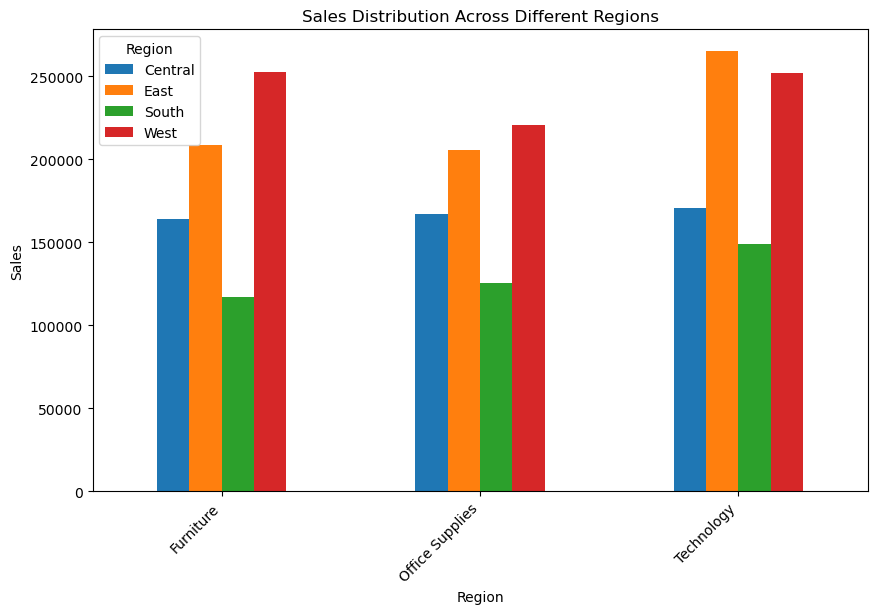

In [2]:
# Barchart showing the sales distribution across different regions
category_region_performance = df.pivot_table(index='Category', columns='Region', values='Sales', aggfunc='sum')

category_region_performance.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Region')
plt.ylabel('Sales')
plt.title('Sales Distribution Across Different Regions')
plt.xticks(rotation=45, ha='right')
plt.show()



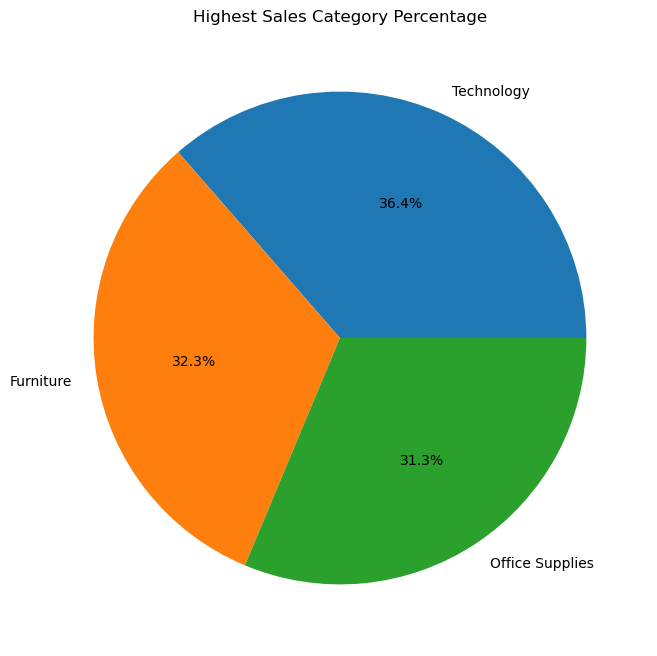

In [3]:
# pie chart showing the highest sales for each category
highest_sales_category_Percentage= df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
highest_sales_category_Percentage.plot(kind = 'pie', autopct='%1.1f%%', figsize=(8, 8))
plt.title('Highest Sales Category Percentage')
plt.ylabel("  ")
plt.show()

In [ ]:
# Visualization showing the Sum sales for each subcategory in each category
import plotly.express as px
Sum_sales_sub_category_in_category = df.groupby(['Category', 'Sub-Category'])['Sales'].sum().reset_index()
Sum_sales_sub_category_in_category


,Category,Sub-Category,Sales
0,Furniture,Bookcases,114879.9963
1,Furniture,Chairs,328449.1030
2,Furniture,Furnishings,91705.1640
3,Furniture,Tables,206965.5320
4,Office Supplies,Appliances,107532.1610
5,Office Supplies,Art,27118.7920
6,Office Supplies,Binders,203412.7330
7,Office Supplies,Envelopes,16476.4020
8,Office Supplies,Fasteners,3024.2800
9,Office Supplies,Labels,12486.3120


In [5]:
fig = px.sunburst(Sum_sales_sub_category_in_category, path=['Category','Sub-Category'], values='Sales',
                   title = 'Sales Breakdown: Category + Sub-Category',
                    width =800, height= 800 )
fig.show()    
                

In [6]:

!pip install kaleido==0.2.1

Defaulting to user installation because normal site-packages is not writeable
  Using cached kaleido-0.2.1-py2.py3-none-win_amd64.whl.metadata (15 kB)
Using cached kaleido-0.2.1-py2.py3-none-win_amd64.whl (65.9 MB)


In [7]:
fig.write_image(
    "IMAGES/Sales Breakdown.png",
    width=1200,
    height=800,
    scale=2
)

In [8]:
df.to_csv('Visualization_Ready_Superstore.csv', index=False)